# Programming for AI – Assignment Solution

**Course:** Programming for AI  
**Topics Covered:**

1. Multiple Linear Regression (Fitting & Actual vs. Predicted Visualizations)
2. Polynomial Feature Engineering & Comparison with Ordinary Linear Regression
3. Gradient Descent Implementation from Scratch for Polynomial Regression & Cost Curve Analysis


---

## Import Required Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


---

## Step 0: Load and Inspect the Dataset

The dataset contains 20 records with 3 independent variables (`Years_Experience`, `Test_Score`, `Projects_Completed`) and 1 dependent target variable (`Salary`).


In [2]:
# Load dataset
dataset = pd.read_csv('assignment_dataset.csv')
print("Dataset Shape:", dataset.shape)
dataset.head(10)


Dataset Shape: (20, 4)


,Years_Experience,Test_Score,Projects_Completed,Salary
0,4.4,96,13,101300.0
1,9.6,82,14,163000.0
2,7.6,70,9,129100.0
3,6.4,69,4,109100.0
4,2.4,57,15,78900.0
5,2.4,91,2,70200.0
6,1.5,61,5,61700.0
7,8.8,75,3,139400.0
8,6.4,63,9,113100.0
9,7.4,93,5,129400.0


In [3]:
# Dataset summary statistics
dataset.describe()


,Years_Experience,Test_Score,Projects_Completed,Salary
count,20.000000,20.000000,20.000000,20.000000
mean,5.120000,72.500000,8.100000,102760.000000
std,2.774622,12.159034,4.423621,32257.914574
min,1.200000,56.000000,2.000000,61700.000000
25%,2.675000,62.500000,4.750000,76500.000000
50%,4.650000,71.000000,7.000000,98500.000000
75%,7.450000,80.500000,11.500000,129175.000000
max,9.700000,96.000000,15.000000,163000.000000


---

## Question 1: Multiple Linear Regression – Visualization and Fitting

### 1.1 Model Training

In this section, we extract all three independent variables ($X_1, X_2, X_3$) into matrix `X` and target `y`. We fit a Multiple Linear Regression model using `sklearn.linear_model.LinearRegression`.


In [4]:
# Separate features and target
X = dataset[['Years_Experience', 'Test_Score', 'Projects_Completed']].values
y = dataset['Salary'].values

# Fit Multiple Linear Regression Model
mlr_model = LinearRegression()
mlr_model.fit(X, y)

# Predictions
y_pred_mlr = mlr_model.predict(X)

# Print coefficients
print("Intercept (b0):", mlr_model.intercept_)
for feature, coef in zip(['Years_Experience', 'Test_Score', 'Projects_Completed'], mlr_model.coef_):
    print(f"Coefficient for {feature}: {coef:.2f}")

# Evaluation Metrics
print(f"Mean Squared Error (MSE): {mean_squared_error(y, y_pred_mlr):.2f}")
print(f"R² Score: {r2_score(y, y_pred_mlr):.4f}")


Intercept (b0): 26140.861153650374
Coefficient for Years_Experience: 10997.87
Coefficient for Test_Score: 177.22
Coefficient for Projects_Completed: 921.22
Mean Squared Error (MSE): 10798859.85
R² Score: 0.9891


### 1.2 Visualization: Actual vs. Fitted / Predicted Values

Because multiple features reside in a higher-dimensional feature space ($4D$ including target), they cannot be properly represented by a single 2D line. An **Actual vs. Predicted** plot provides an intuitive visualization: the closer points fall along the red 45-degree reference line ($y = \hat{y}$), the more accurate the fit.


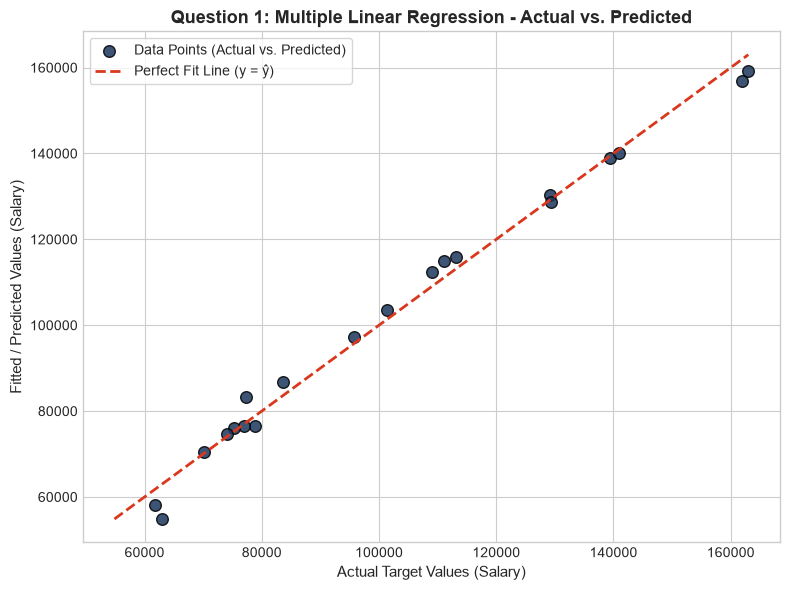

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_mlr, color='#1B365D', edgecolors='k', s=70, alpha=0.85, label='Data Points (Actual vs. Predicted)')
# 45-degree identity reference line
min_val = min(y.min(), y_pred_mlr.min())
max_val = max(y.max(), y_pred_mlr.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#D9381E', linestyle='--', linewidth=2, label='Perfect Fit Line (y = ŷ)')

plt.title('Question 1: Multiple Linear Regression - Actual vs. Predicted', fontsize=13, fontweight='bold')
plt.xlabel('Actual Target Values (Salary)', fontsize=11)
plt.ylabel('Fitted / Predicted Values (Salary)', fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


### 1.3 Individual Feature Relationships with Model Predictions

We also visualize individual features against the target while retaining the multi-feature model fit.


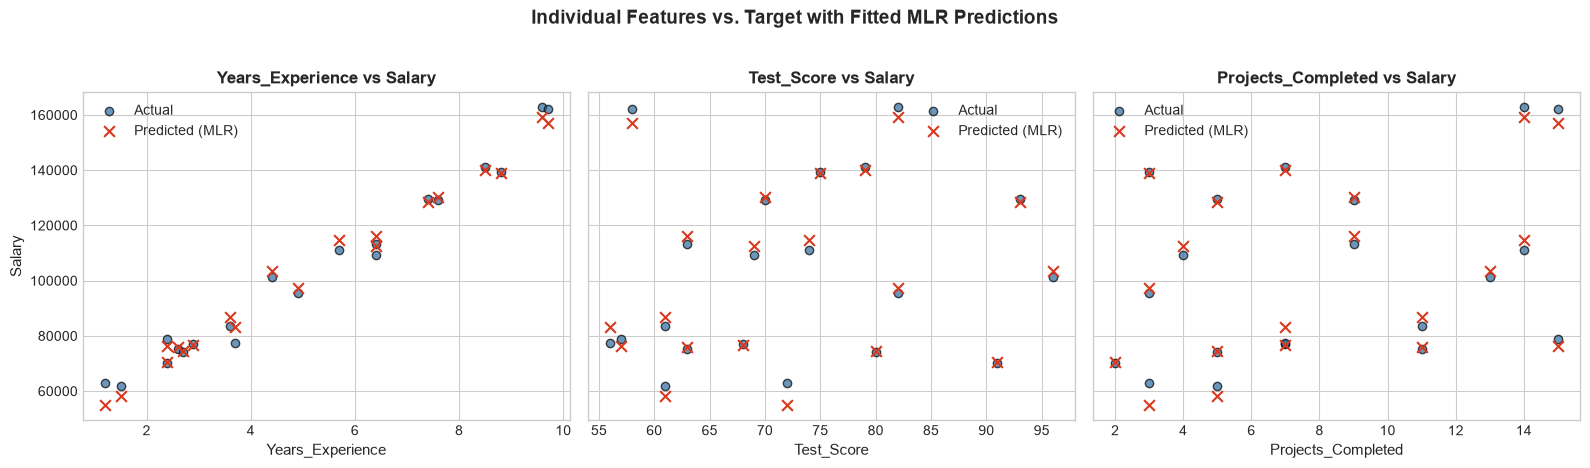

In [6]:
features = ['Years_Experience', 'Test_Score', 'Projects_Completed']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for i, col in enumerate(features):
    axes[i].scatter(dataset[col], y, color='#2E6B9E', alpha=0.7, edgecolors='k', label='Actual')
    axes[i].scatter(dataset[col], y_pred_mlr, color='#D9381E', marker='x', s=60, label='Predicted (MLR)')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_title(f'{col} vs Salary', fontsize=12, fontweight='bold')
    axes[i].legend()

axes[0].set_ylabel('Salary', fontsize=11)
plt.suptitle('Individual Features vs. Target with Fitted MLR Predictions', fontsize=14, y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()


---

## Question 2: Polynomial Regression and Feature Engineering

### 2.1 Generating Polynomial Features

Here, we focus on the relationship between `Years_Experience` and `Salary` to illustrate non-linear curve fitting. We compare:

1. Ordinary Simple Linear Regression (Degree 1)
2. Polynomial Regression with quadratic term (Degree 2)
3. Higher-order Polynomial Regression with cubic term (Degree 3)


In [7]:
# Feature selection for polynomial study
x_exp = dataset[['Years_Experience']].values

# 1. Ordinary Linear Regression (Degree 1)
lin_reg = LinearRegression()
lin_reg.fit(x_exp, y)
y_pred_lin = lin_reg.predict(x_exp)

# 2. Polynomial Regression (Degree 2)
poly_feat_d2 = PolynomialFeatures(degree=2)
x_poly_d2 = poly_feat_d2.fit_transform(x_exp)
poly_reg_d2 = LinearRegression()
poly_reg_d2.fit(x_poly_d2, y)
y_pred_poly2 = poly_reg_d2.predict(x_poly_d2)

# 3. Higher-order Polynomial Regression (Degree 3)
poly_feat_d3 = PolynomialFeatures(degree=3)
x_poly_d3 = poly_feat_d3.fit_transform(x_exp)
poly_reg_d3 = LinearRegression()
poly_reg_d3.fit(x_poly_d3, y)
y_pred_poly3 = poly_reg_d3.predict(x_poly_d3)

# Metrics comparison
results_comparison = pd.DataFrame({
    'Model': ['Ordinary Linear (Degree 1)', 'Polynomial (Degree 2)', 'Polynomial (Degree 3)'],
    'MSE': [mean_squared_error(y, y_pred_lin), mean_squared_error(y, y_pred_poly2), mean_squared_error(y, y_pred_poly3)],
    'R² Score': [r2_score(y, y_pred_lin), r2_score(y, y_pred_poly2), r2_score(y, y_pred_poly3)]
})
results_comparison


,Model,MSE,R² Score
0,Ordinary Linear (Degree 1),2.452894e+07,0.975187
1,Polynomial (Degree 2),1.730515e+07,0.982494
2,Polynomial (Degree 3),1.635302e+07,0.983457


### 2.2 Visualization of Fitted Regression Curves


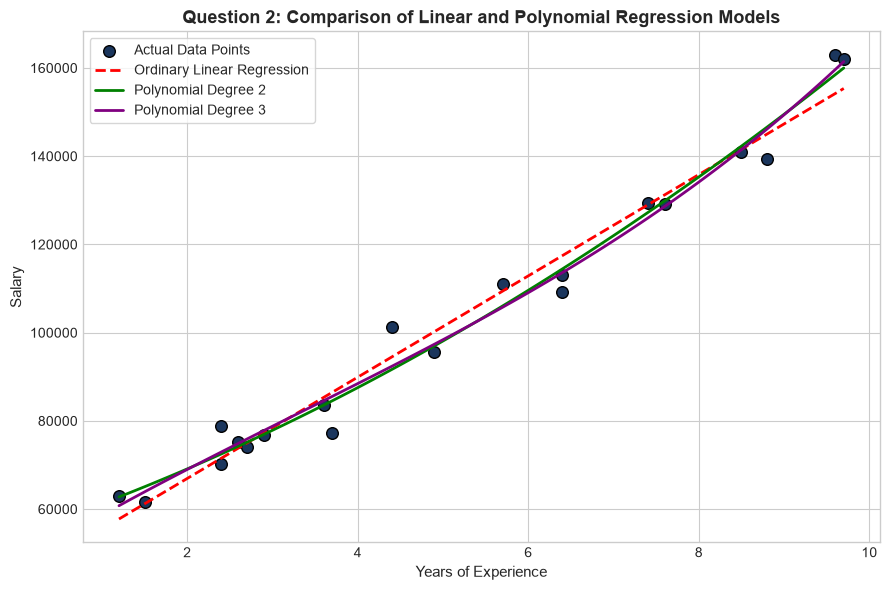

In [13]:
# Smooth grid for plotting clean continuous curves
x_grid = np.arange(x_exp.min(), x_exp.max() + 0.1, 0.1).reshape(-1, 1)

plt.figure(figsize=(9, 6))
plt.scatter(x_exp, y, color='#1B365D', s=70, edgecolors='k', label='Actual Data Points')
plt.plot(x_grid, lin_reg.predict(x_grid), color='red', linestyle='--', linewidth=2, label='Ordinary Linear Regression')
plt.plot(x_grid, poly_reg_d2.predict(poly_feat_d2.transform(x_grid)), color='green', linewidth=2, label='Polynomial Degree 2')
plt.plot(x_grid, poly_reg_d3.predict(poly_feat_d3.transform(x_grid)), color='purple', linewidth=2, label='Polynomial Degree 3')

plt.title('Question 2: Comparison of Linear and Polynomial Regression Models', fontsize=13, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=11)
plt.ylabel('Salary', fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


### 2.3 Discussion: How Polynomial Features Learn Non-Linear Relationships

- **Linear Model Limitation:** Standard linear regression assumes constant rate of change ($y = w_1 x + b$). When underlying physical or financial phenomena accelerate (e.g., salary growth compounding with experience), straight lines suffer from high bias (underfitting).
- **Linear in Parameters, Non-Linear in Features:** By augmenting the input vector with higher-order power transformations $[x, x^2, x^3, \dots]$, the hypothesis function becomes:
  $$\hat{y} = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + \dots$$
  While the geometric response surface in original feature space curves to capture exponential/polynomial trends, the optimization problem remains linear with respect to the weights $w$, enabling standard convex linear solvers to find the global optimum efficiently.


---

## Question 3: Gradient Descent for Polynomial Regression

### 3.1 Mathematical Formulation and Gradient Descent Implementation from Scratch

1. **Hypothesis Function:**
   $$\hat{y} = X_{poly} W + b$$
2. **Mean Squared Error (MSE) Loss:**
   $$J(W, b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$
3. **Parameter Gradient Updates:**
   $$\frac{\partial J}{\partial W} = \frac{1}{m} X_{poly}^T (\hat{y} - y), \quad \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$
   $$W := W - \alpha \frac{\partial J}{\partial W}, \quad b := b - \alpha \frac{\partial J}{\partial b}$$

_Note on Feature Scaling:_ Higher-degree polynomial powers ($x^2, x^3$) span much wider numerical ranges than $x$. Applying standard scaling ($\mu=0, \sigma=1$) is essential so that gradient descent converges smoothly without oscillating or diverging.


In [9]:
# Feature engineering (Degree 2 polynomial features without intercept column)
poly_gd = PolynomialFeatures(degree=2, include_bias=False)
X_poly_raw = poly_gd.fit_transform(x_exp)

# Feature Scaling
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Gradient Descent Training Algorithm
def gradient_descent(X, y, learning_rate=0.05, iterations=1000):
    m, n = X.shape
    # Initial parameters
    np.random.seed(42)
    W = np.zeros(n)
    b = 0.0
    cost_history = []
    
    for i in range(iterations):
        # 1. Compute predictions
        y_pred = np.dot(X, W) + b
        
        # 2. Compute Mean Squared Error Loss
        error = y_pred - y
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        cost_history.append(loss)
        
        # 3. Compute gradients
        dW = (1 / m) * np.dot(X.T, error)
        db = (1 / m) * np.sum(error)
        
        # 4. Iteratively update parameters using learning rate
        W -= learning_rate * dW
        b -= learning_rate * db
        
    return W, b, cost_history

# Train model using Gradient Descent
alpha = 0.05
epochs = 1200
W_trained, b_trained, loss_curve = gradient_descent(X_poly_scaled, y, learning_rate=alpha, iterations=epochs)

print("Trained Weights (W):", W_trained)
print("Trained Bias (b):", b_trained)
print(f"Final Loss at Iteration {epochs}: {loss_curve[-1]:.2f}")


Trained Weights (W): [16950.25599962 14363.22719167]
Trained Bias (b): 102759.99999999987
Final Loss at Iteration 1200: 8659403.20


### 3.2 Plotting Loss over Iterations (Cost Convergence Curve)


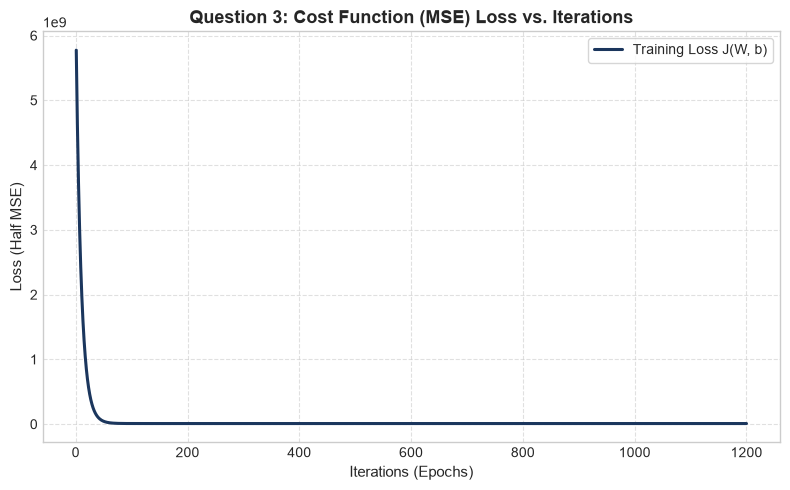

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_curve, color='#1B365D', linewidth=2.2, label='Training Loss J(W, b)')
plt.title('Question 3: Cost Function (MSE) Loss vs. Iterations', fontsize=13, fontweight='bold')
plt.xlabel('Iterations (Epochs)', fontsize=11)
plt.ylabel('Loss (Half MSE)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


### 3.3 Evaluating the Trained Gradient Descent Model on the Dataset


--- Gradient Descent Model Evaluation ---
Trained MSE: 17318780.15
Trained R² Score: 0.9825


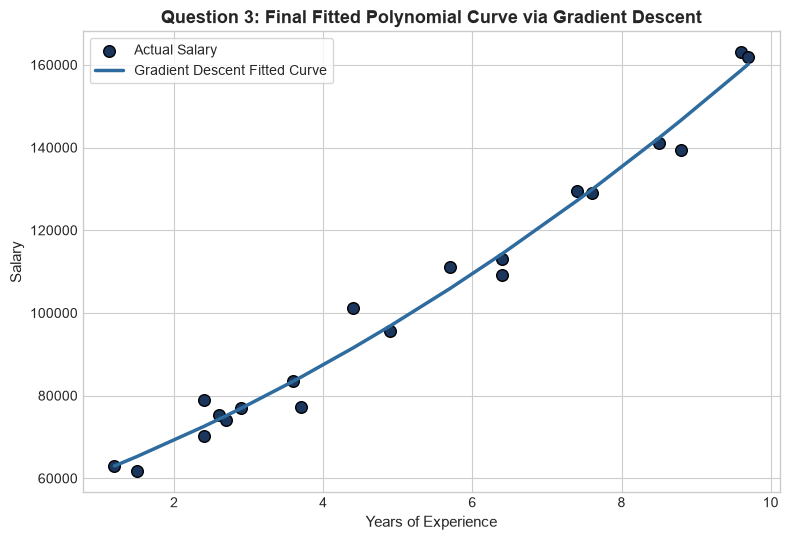

In [11]:
# Evaluate model predictions
y_pred_gd = np.dot(X_poly_scaled, W_trained) + b_trained

mse_gd = mean_squared_error(y, y_pred_gd)
r2_gd = r2_score(y, y_pred_gd)

print("--- Gradient Descent Model Evaluation ---")
print(f"Trained MSE: {mse_gd:.2f}")
print(f"Trained R² Score: {r2_gd:.4f}")

# Visualizing Gradient Descent Fit against Actual Data
sorted_idx = np.argsort(x_exp.flatten())
x_sorted = x_exp.flatten()[sorted_idx]
y_gd_sorted = y_pred_gd[sorted_idx]

plt.figure(figsize=(8, 5.5))
plt.scatter(x_exp, y, color='#1B365D', s=70, edgecolors='k', label='Actual Salary')
plt.plot(x_sorted, y_gd_sorted, color='#2E6B9E', linewidth=2.5, label='Gradient Descent Fitted Curve')
plt.title('Question 3: Final Fitted Polynomial Curve via Gradient Descent', fontsize=13, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=11)
plt.ylabel('Salary', fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
